# Example for using LET as quantity during optimization.

This example demonstrates how pyRadPlan handles additional quantities such as LET.

To display this script in a Jupyter Notebook, you need to install jupytext via pip and run the following command.
This will create a .ipynb file in the same directory:

```bash
pip install jupytext
jupytext --to notebook path/to/this/file/pencilbeam_proton_let.py

In [1]:
# Import necessary libraries
import logging

import numpy as np

from pyRadPlan import (
    IonPlan,
    generate_stf,
    calc_dose_influence,
    fluence_optimization,
    plot_slice,
    load_tg119,
)

from pyRadPlan.gui import launch_viewer, GUI_AVAILABLE
from pyRadPlan.optimization.objectives import SquaredDeviation, SquaredOverdosing, MeanDose

logging.basicConfig(level=logging.INFO)

D:\Python\pyRadPlan\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Just like in the other examples, we load the ct and cst, create the Plan and Steeringinformation

In [2]:
# load TG119
ct, cst = load_tg119()

# Create a plan object
pln = IonPlan(radiation_mode="protons", machine="Generic")
pln.prop_opt = {"solver": "scipy", "convert_dose_objectives": False}

# Generate Steering Geometry ("stf")
stf = generate_stf(ct, cst, pln)

# Calculate Dose Influence Matrix ("dij")
dij = calc_dose_influence(ct, cst, stf, pln)

Beam:   0%|          | 0/1 [00:00<?, ?b/s]

Beam: 100%|██████████| 1/1 [00:01<00:00,  1.11s/b]

INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation using 'Hong Particle Pencil-Beam' Dose Engine...


INFO:pyRadPlan.dose.engines._base:Dose Grid not set. Using default resolution.


INFO:pyRadPlan.dose.engines._base:Dose Grid has Dimensions (101,101,65) with resolution x=5.000000, y=5.000000, z=5.000000.


...

Ray: 100%|██████████| 316/316 [00:23<00:00, 15.44r/s]

Beam: 100%|██████████| 1/1 [00:25<00:00, 25.71s/b]

INFO:pyRadPlan.dose.engines._base_pencilbeam:Finalizing dose calculation...


INFO:pyRadPlan.dose.engines._base_pencilbeam:Done in 0.012102 seconds.


INFO:pyRadPlan.dose.engines._base:Dose influence matrix calculation done in 27.07 seconds.


When defining the objective functions and its parameters, one can add the respective quantity.
Standard quantity is physical dose.

In [3]:
# OAR
cst.vois[0].objectives = [
    SquaredOverdosing(priority=10.0, d_max=1.0),
    SquaredOverdosing(priority=5.0, d_max=1.0, quantity="let_dose"),
]
# Target
cst.vois[1].objectives = [SquaredDeviation(priority=100.0, d_ref=3.0)]  # Target
# BODY
cst.vois[2].objectives = [
    MeanDose(priority=1.0, d_ref=0.0),
    SquaredOverdosing(priority=10.0, d_max=2.0),
]

We then calculate the optimized fluence and the corresponding result of the plan.
Additionally we plot both the physical dose and the LET.

INFO:pyRadPlan.optimization.problems._optiprob:Objective doses are interpreted per fraction (dose_convention='per_fraction').


INFO:pyRadPlan.dij._dij:Converted Dij to namespace 'array_api_compat.cupy'


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.cupy


INFO:pyRadPlan.quantities._base:Optimization will use array backend: array_api_compat.cupy


INFO:pyRadPlan.util.keyboard_listener:Press 'q' or ESC to stop optimization early.


INFO:pyRadPlan.optimization.solvers._base_solvers:Starting optimization using SciPy minimize


INFO:pyRadPlan.util.keyboard_listener:Optimization aborted by user. Returning last known iterate.


INFO:pyRadPlan.optimization.problems._nonlin_fluence:228 Objective function evaluations, avg. time: 0.0144236 +/- 0.00675206 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:228 Derivative evaluations, avg. time: 0.018635 +/- 0.00469045 s


INFO:pyRadPlan.optimization.problems._nonlin_fluence:Solver time: 8.12621 s


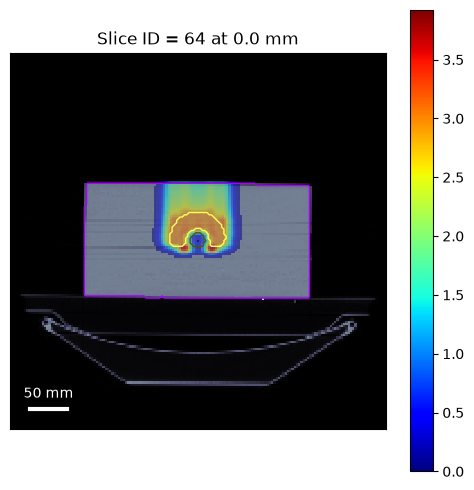

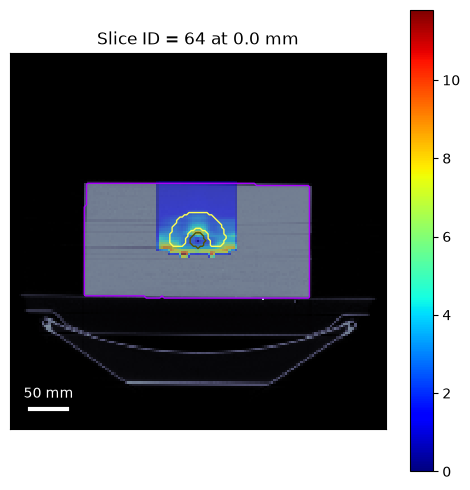

In [4]:
fluence = fluence_optimization(ct, cst, stf, dij, pln)

# Compute the result
result = dij.compute_result_ct_grid(fluence)

if GUI_AVAILABLE:
    # Use the GUI if [gui] dependencies are installed
    launch_viewer(ct, cst, result)
else:
    # Choose a slice to visualize
    view_slice = int(np.round(ct.size[2] / 2))

    # Visualize
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["physical_dose"],
        view_slice=view_slice,
    )
    plot_slice(
        image_volume=ct,
        cst=cst,
        overlay=result["let"],
        view_slice=view_slice,
    )